## Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), '../..'))

if os.getcwd() != project_root:
    os.chdir(project_root)

if project_root not in sys.path:
    sys.path.append(project_root)

In [2]:
from volatility_surface.core.calibration.calibrator import calibrate_snapshot, calibrate_global_essvi, calibrate_global_sabr, calibrate_global_essvi_update, summary, compare
from volatility_surface.core.calibration.objectives import get_objective
from volatility_surface.models.vol_models import get_model
from volatility_surface.plots.vol_plots import plot_surface, plot_slices, plot_total_variance, plot_metrics, plot_compare, plot_all
from time import time
import pandas as pd
pd.set_option('display.max_columns', None)

## Data

In [3]:
#Global dataframes
btc_df = pd.read_parquet('/Users/macbookair/Internship Natixis/2 - Data/parquets/btc_options_data_cleaned.parquet')
eth_df = pd.read_parquet('/Users/macbookair/Internship Natixis/2 - Data/parquets/eth_options_data_cleaned.parquet')

eth_snapshots = {}
for t0 in eth_df.file_timestamp.unique():
    eth_snapshot = eth_df[eth_df.file_timestamp == t0]
    eth_snapshots[f'eth {eth_snapshot.file_timestamp.unique()[0]}'] = eth_snapshot
eth_dates = eth_snapshots.keys()

btc_snapshots = {}
for t0 in btc_df.file_timestamp.unique():
    btc_snapshot = btc_df[btc_df.file_timestamp == t0]
    btc_snapshots[f'btc {btc_snapshot.file_timestamp.unique()[0]}'] = btc_snapshot

print(f'{len(eth_snapshots)} eth snapshots, {len(btc_snapshots)} btc snapshots')

eth = list(eth_snapshots.values())[4]
btc = list(btc_snapshots.values())[4]

14 eth snapshots, 6 btc snapshots


# **Point in time calibration**

## ***Models***

### *eSSVI* - Vega Weighted MSE

In [4]:
t0 = time()
essvi_vwmse = calibrate_global_essvi(df=eth, model=get_model('essvi'),objective=get_objective('vega_wmse'),bid_col='bid_iv', ask_col='ask_iv',   verbose=False)
t1 = time()
print(f'Time taken to calibrate eSSVI from a cold start using a vega WMSE objective function: {round(t1-t0, 1)}s')

Time taken to calibrate eSSVI from a cold start using a vega WMSE objective function: 76.8s


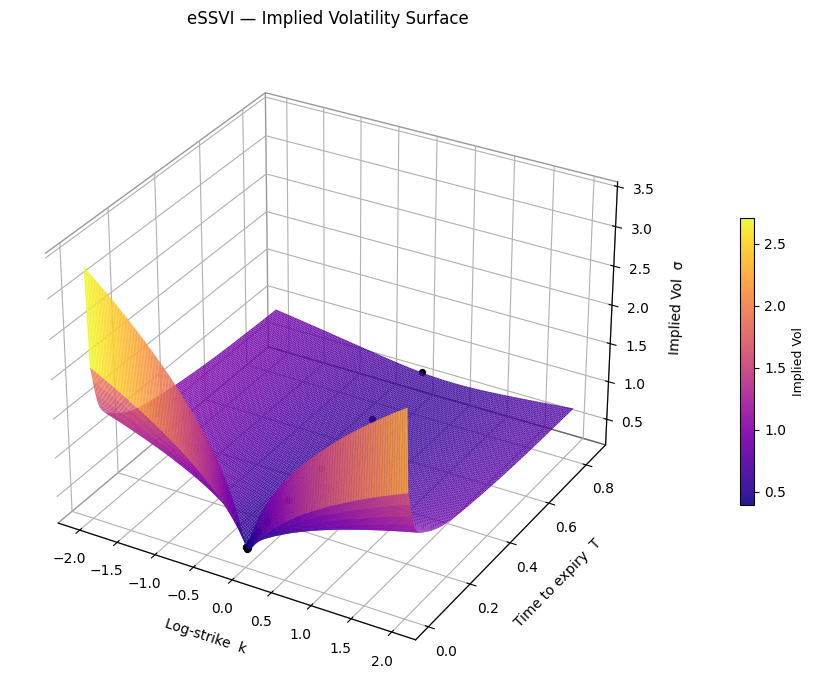

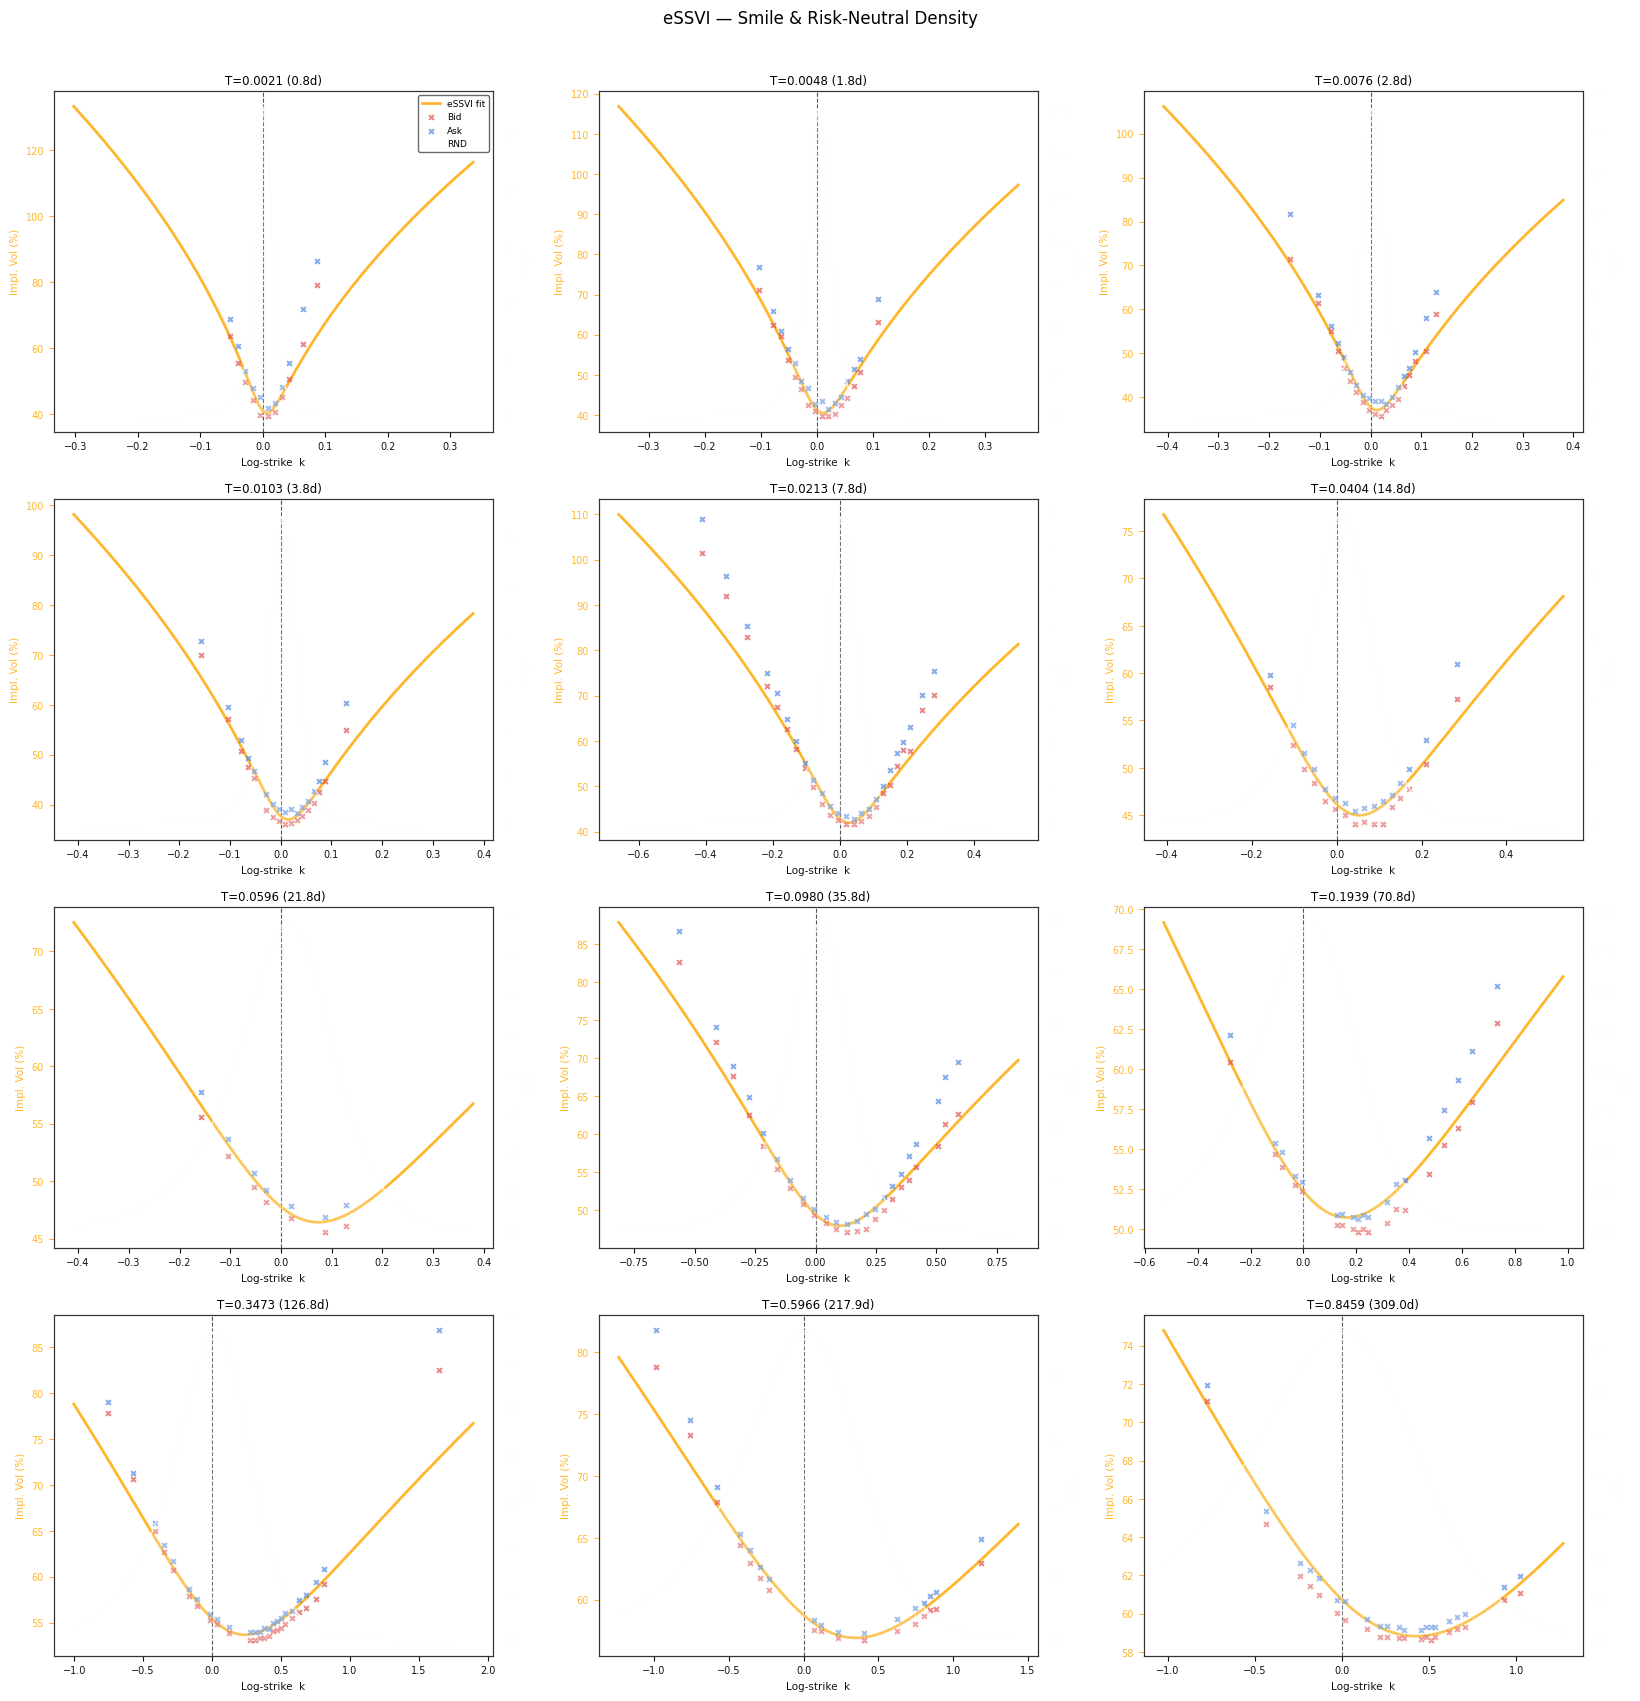

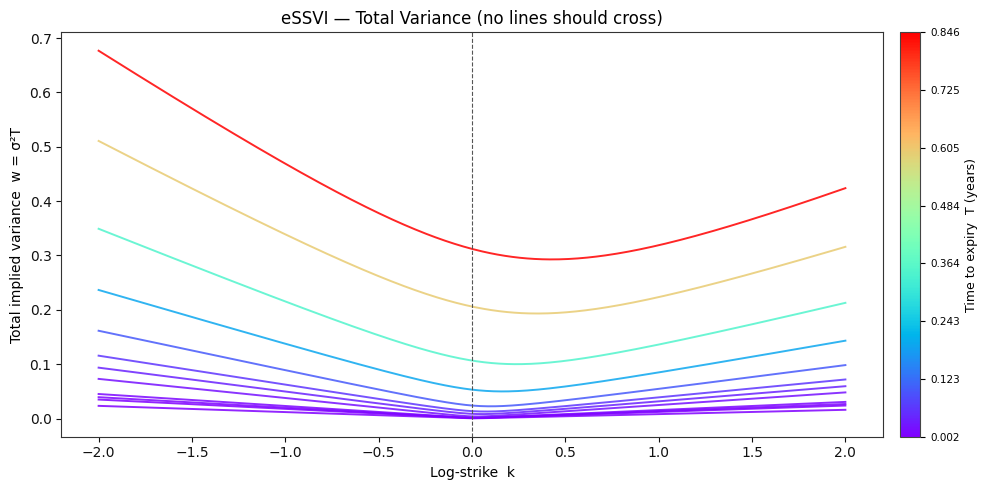

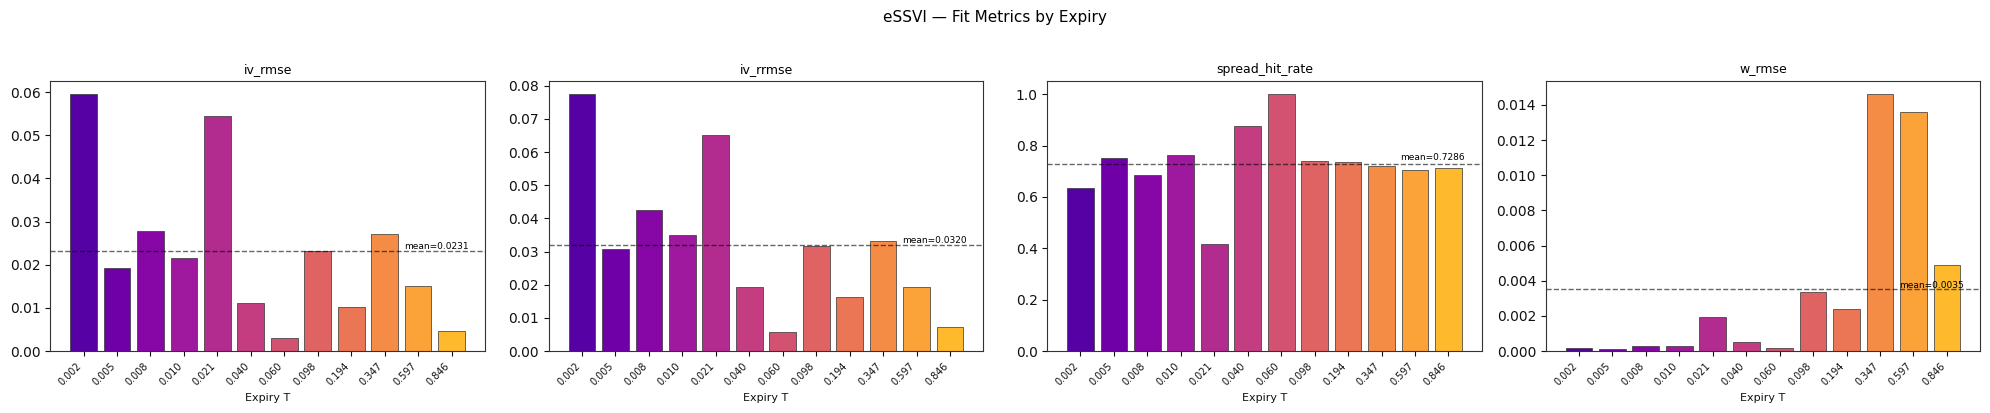

In [5]:
plot_all(essvi_vwmse, df = eth);

### *eSSVI* - IV  RMSE

In [ ]:
t0 = time()
essvi_ivrmse = calibrate_global_essvi(df=eth, model = get_model('essvi'), objective=get_objective('iv_rmse'), bid_col = 'bid_iv', ask_col='ask_iv',verbose=False)
t1 = time()
print(f'Time taken to calibrate eSSVI from a cold start using an IV RMSE objective function: {round(t1-t0, 1)}s')

Time taken to calibrate eSSVI from a cold start using an IV RMSE objective function: 42.1s


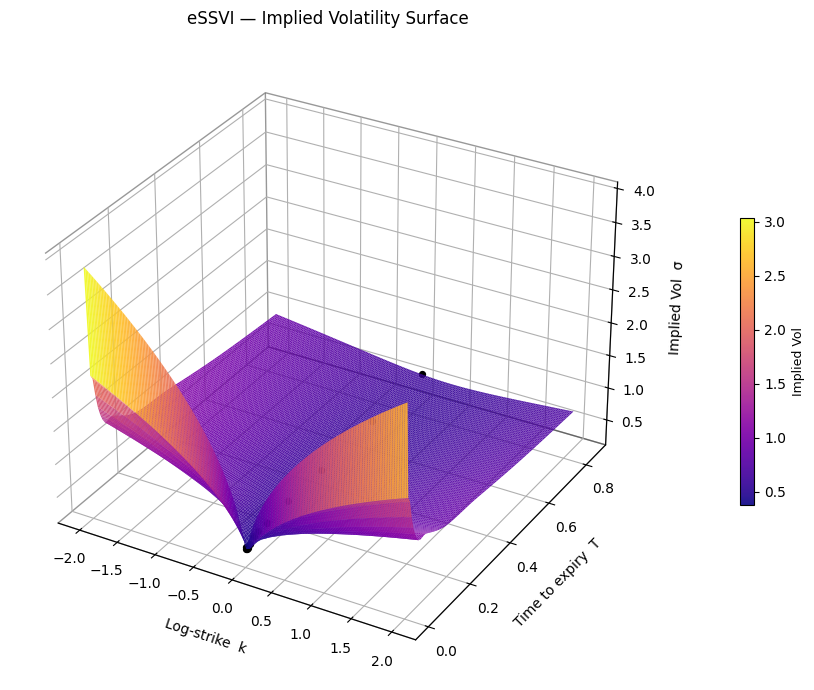

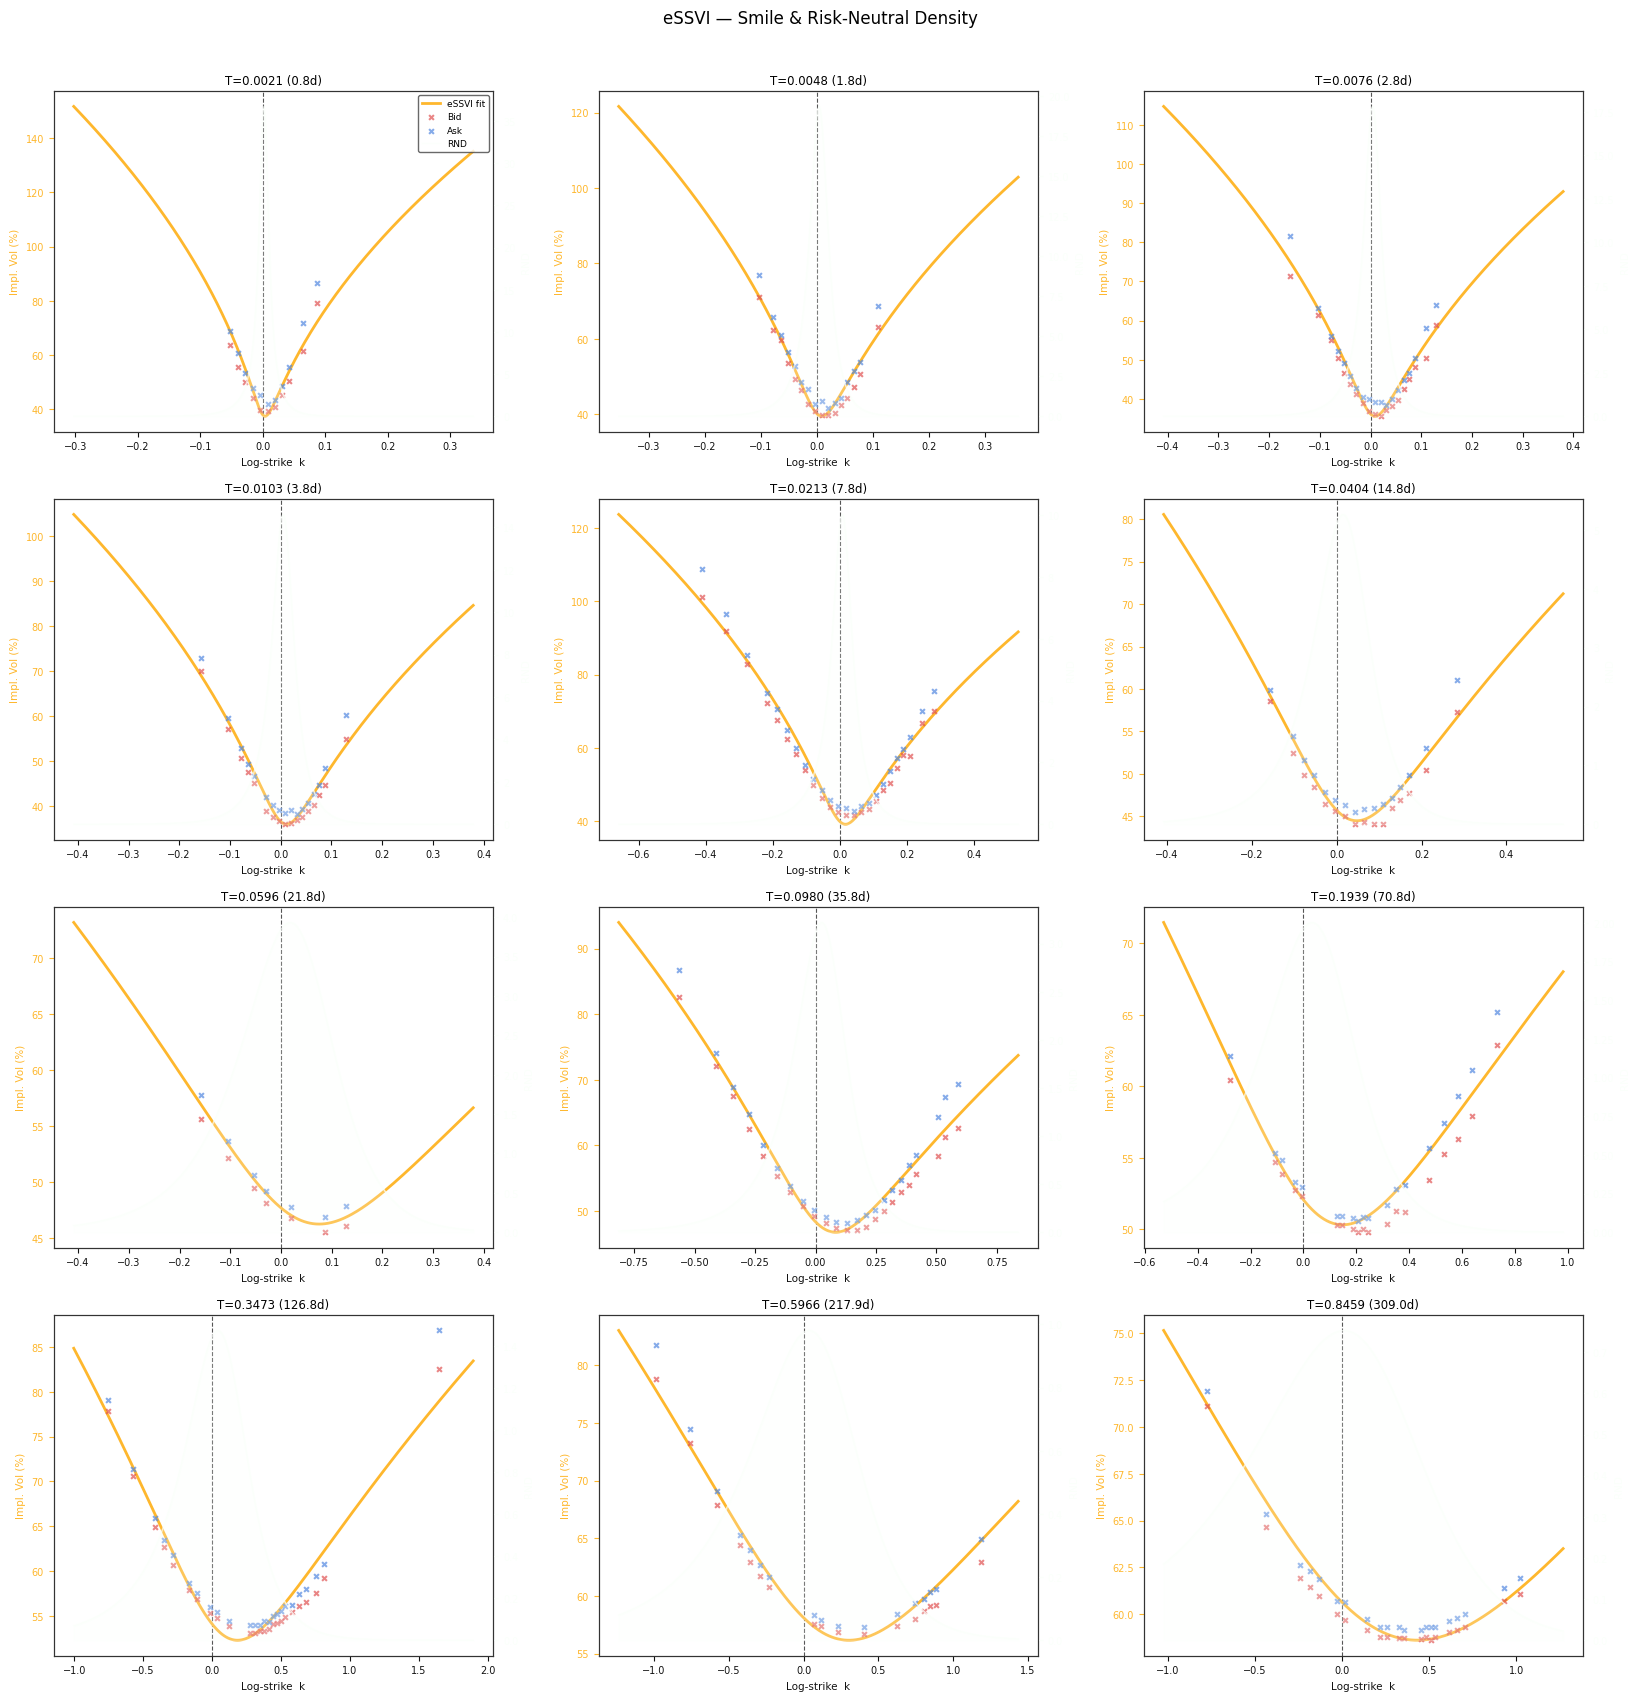

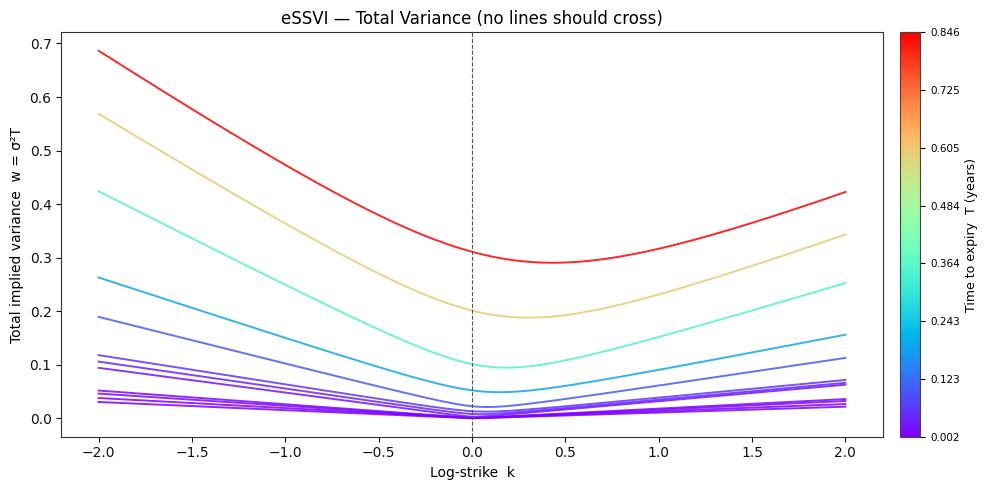

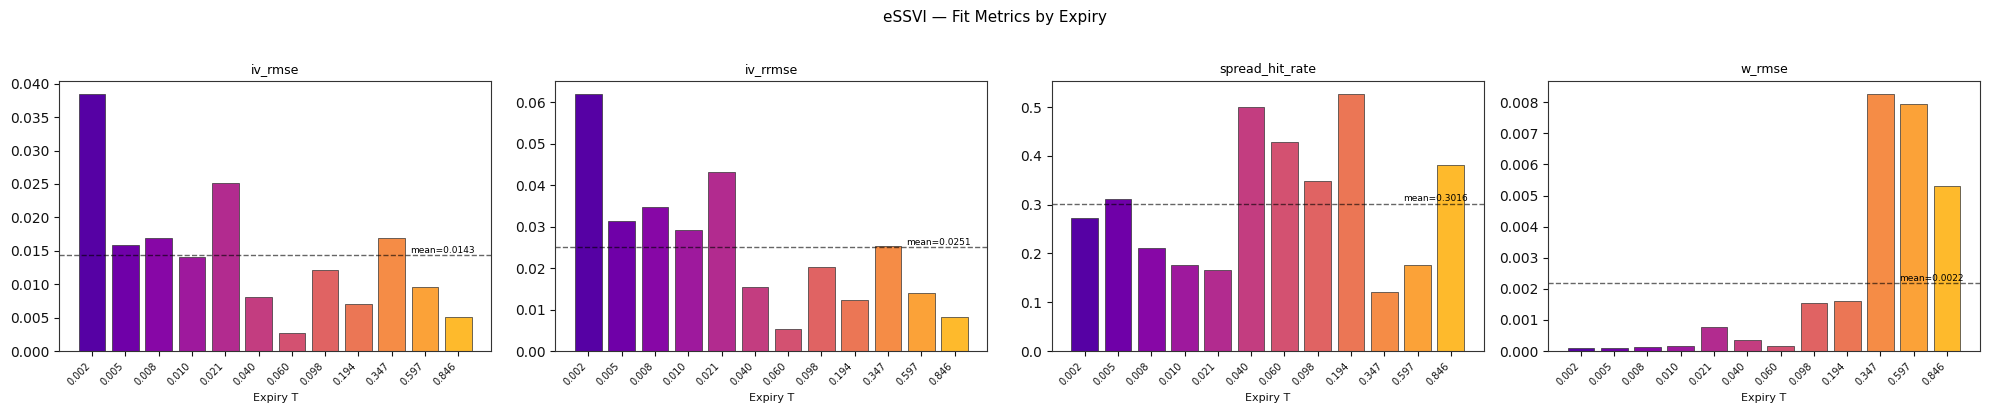

In [7]:
plot_all(essvi_ivrmse, df = eth);

### *SABR* - Vega Weighted MSE (no arbitrage condition)

In [18]:
t0 = time()
sabr_vwmse = calibrate_snapshot(df=eth, model = get_model('sabr'), objective=get_objective('vega_wmse'), bid_col = 'bid_iv', ask_col='ask_iv',verbose=False)
t1 = time()
print(f'Time taken to calibrate eSSVI from a cold start using a vega WMSE objective function: {round(t1-t0, 1)}s')

Time taken to calibrate eSSVI from a cold start using a vega WMSE objective function: 22.2s


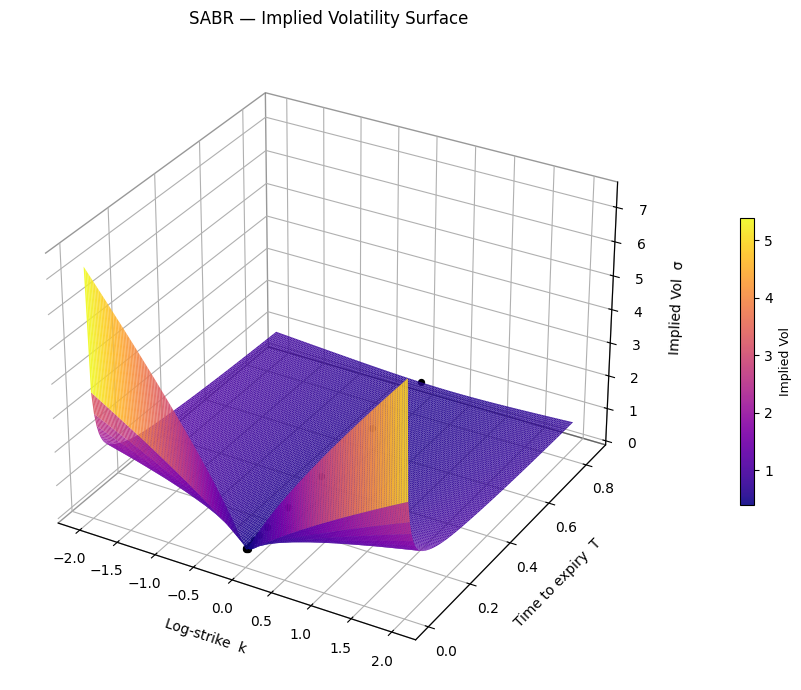

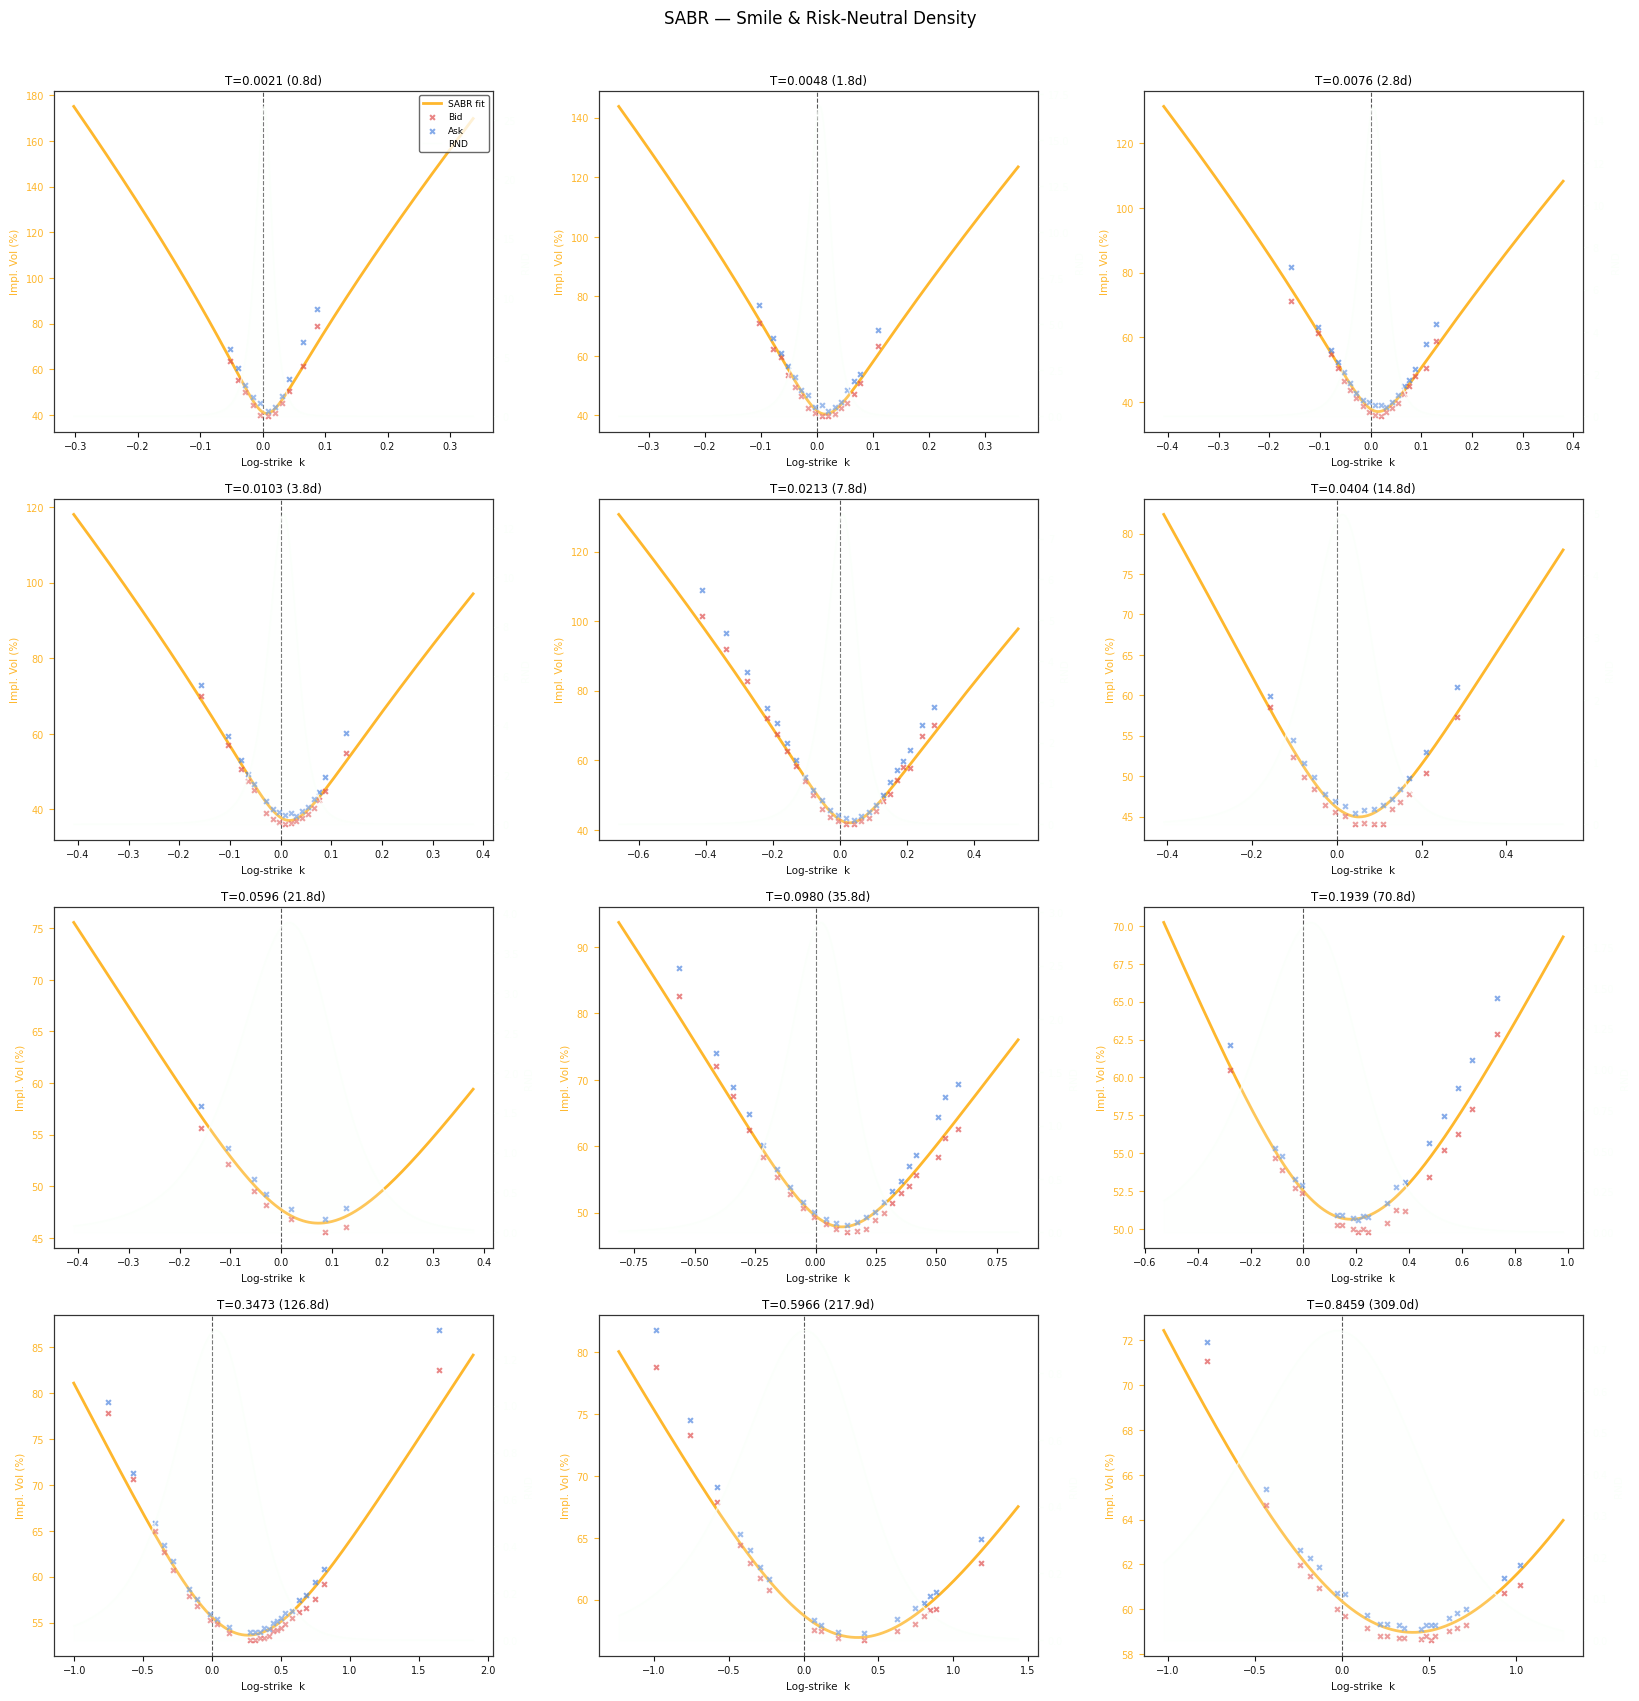

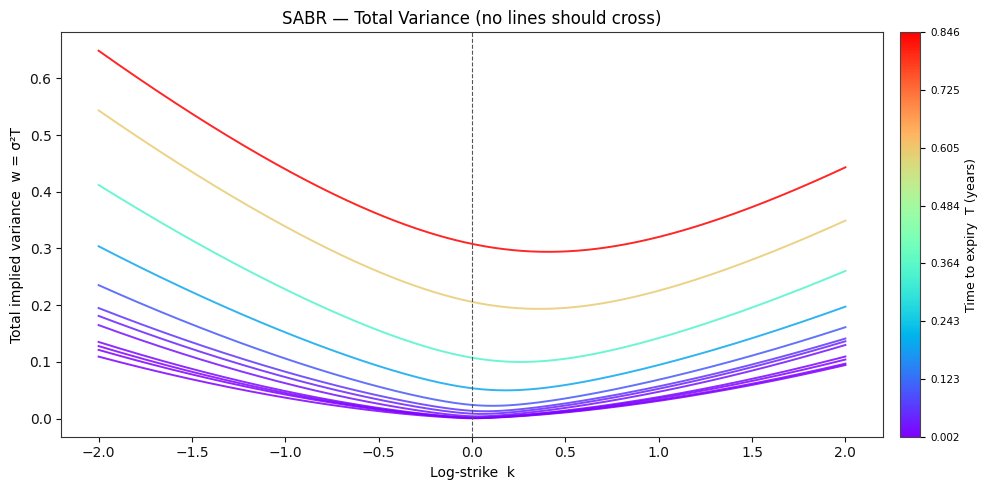

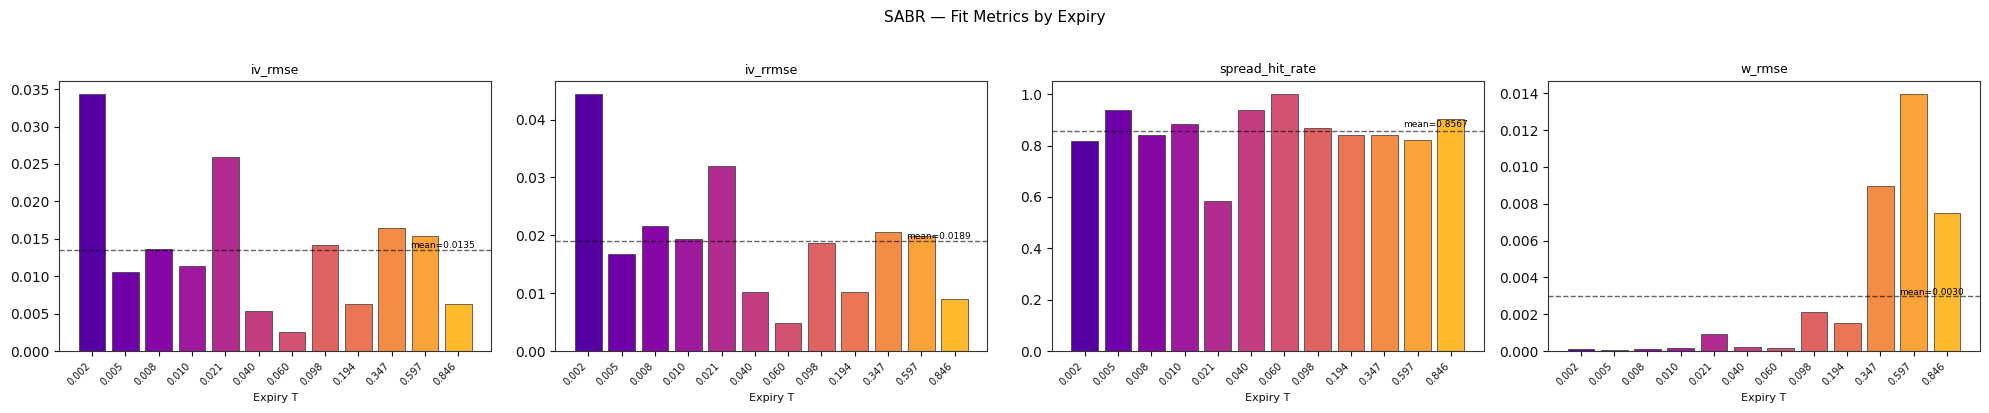

In [19]:
plot_all(sabr_vwmse, df = eth);

### *SABR* - Vega Weighted MSE (arbitrage condition)

In [16]:
t0 = time()
sabr_vwmse_arbfree = calibrate_snapshot(df=eth, model = get_model('sabr'), objective=get_objective('vega_wmse'), bid_col = 'bid_iv', ask_col='ask_iv', enforce_arbfree=True, verbose=False)
t1 = time()
print(f'Time taken to calibrate SABR (arb-free) from a cold start using a vega WMSE objective function: {round(t1-t0, 1)}s')

Time taken to calibrate SABR (arb-free) from a cold start using a vega WMSE objective function: 22.8s


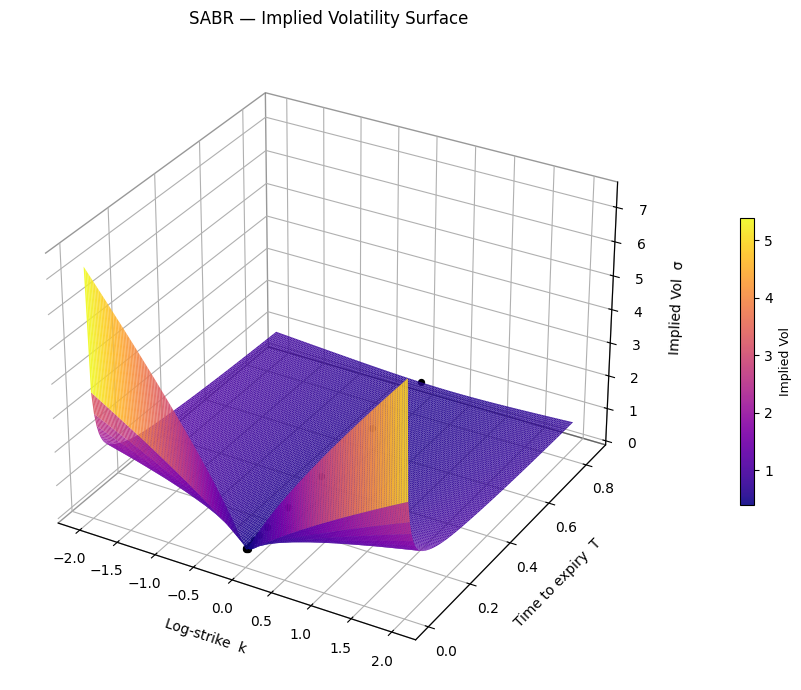

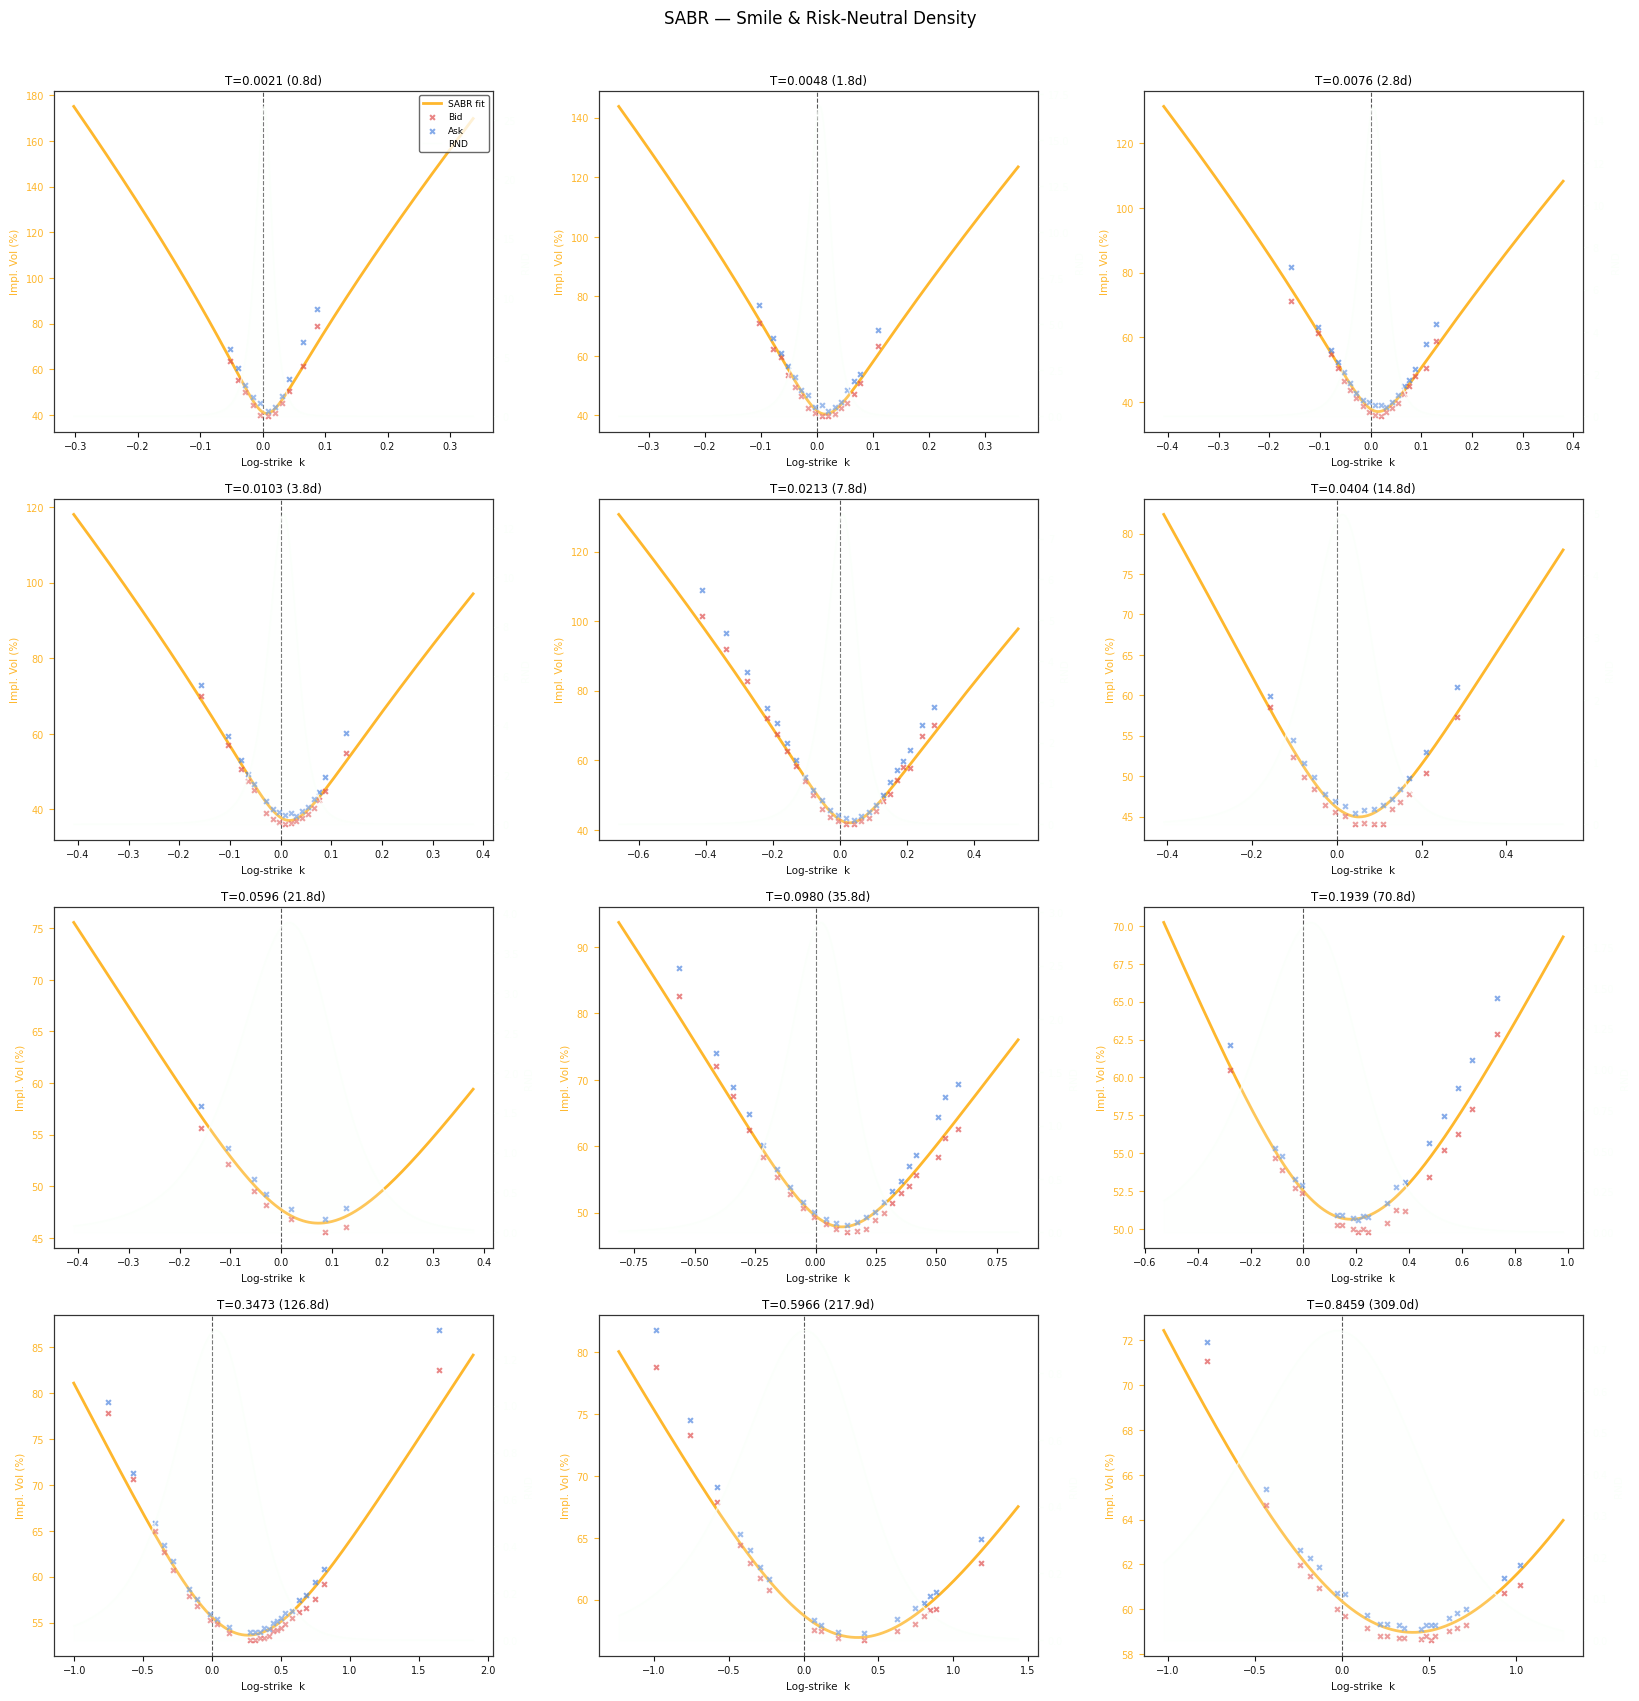

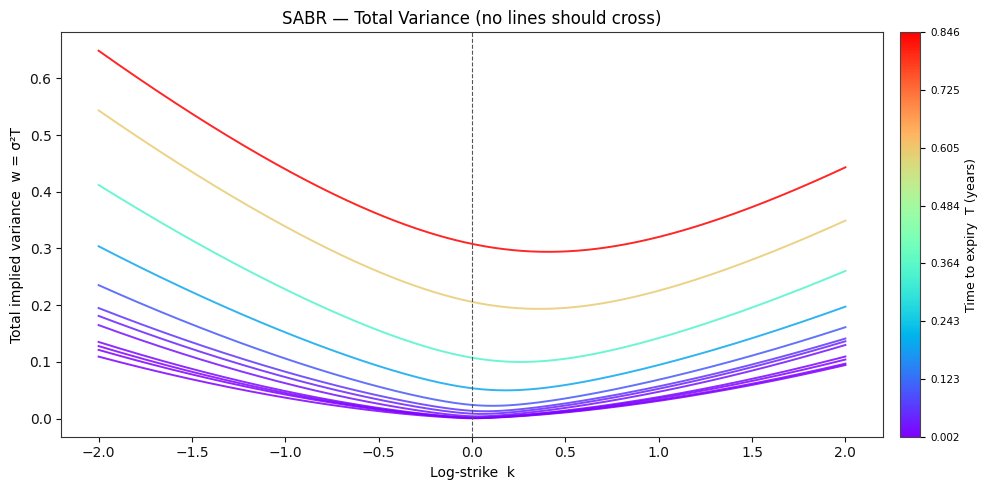

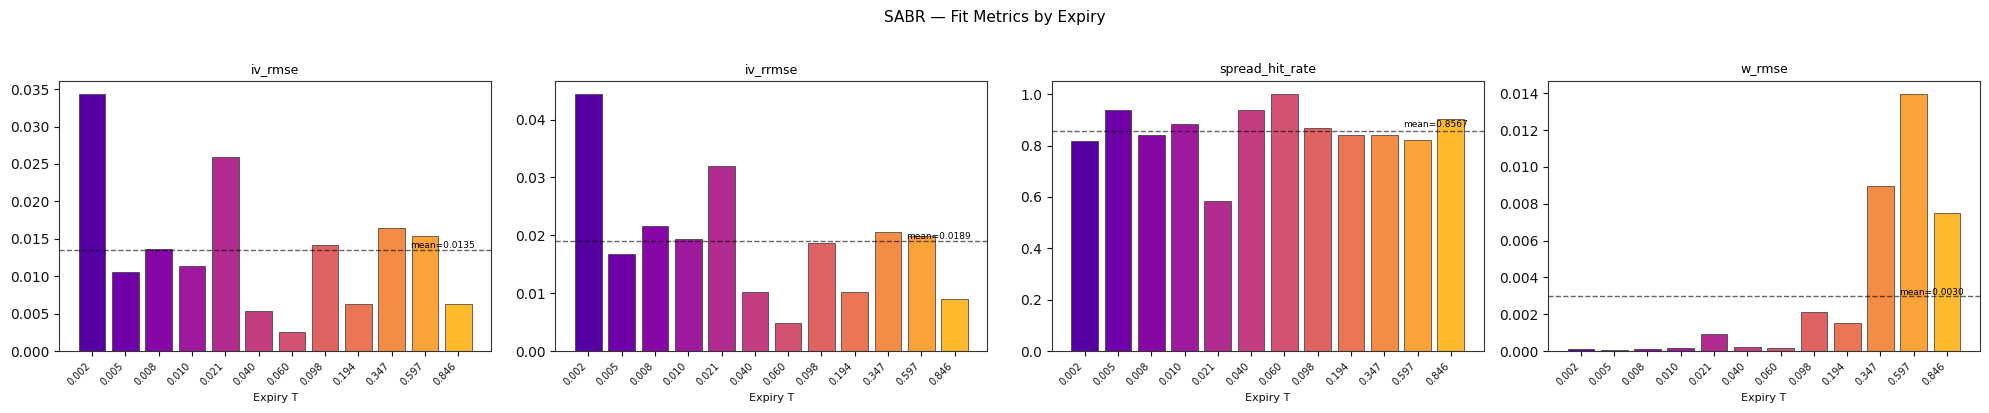

In [17]:
plot_all(sabr_vwmse_arbfree, df = eth);

In [ ]:
t0 = time()
sabr_ivrmse = calibrate_snapshot(df=eth, model = get_model('sabr'), objective=get_objective('iv_rmse'), bid_col = 'bid_iv', ask_col='ask_iv',verbose=False)
t1 = time()
print(f'Time taken to calibrate SABR from a cold start using a IV RMSE objective function: {round(t1-t0, 1)}s')

Time taken to calibrate eSSVI from a cold start using a vega WMSE objective function: 30.2s


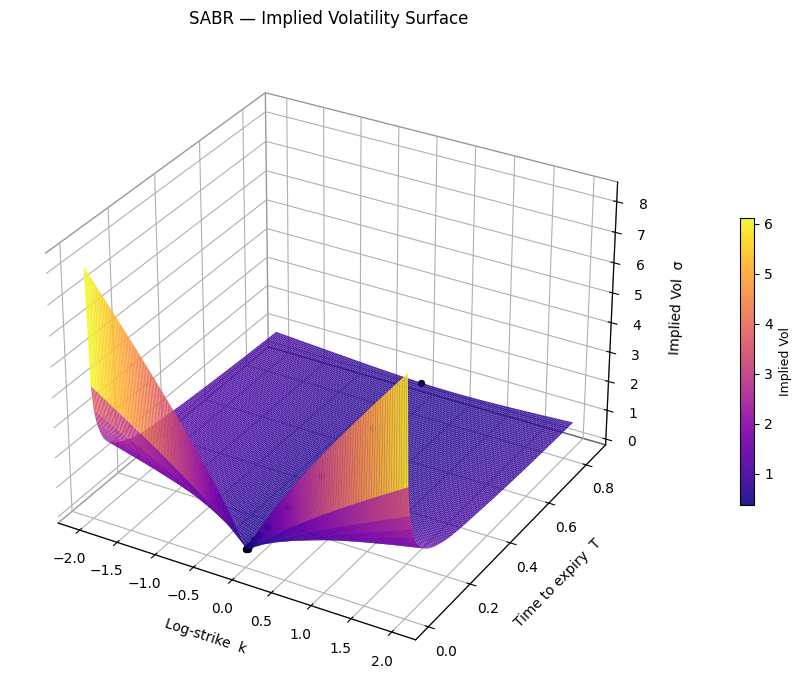

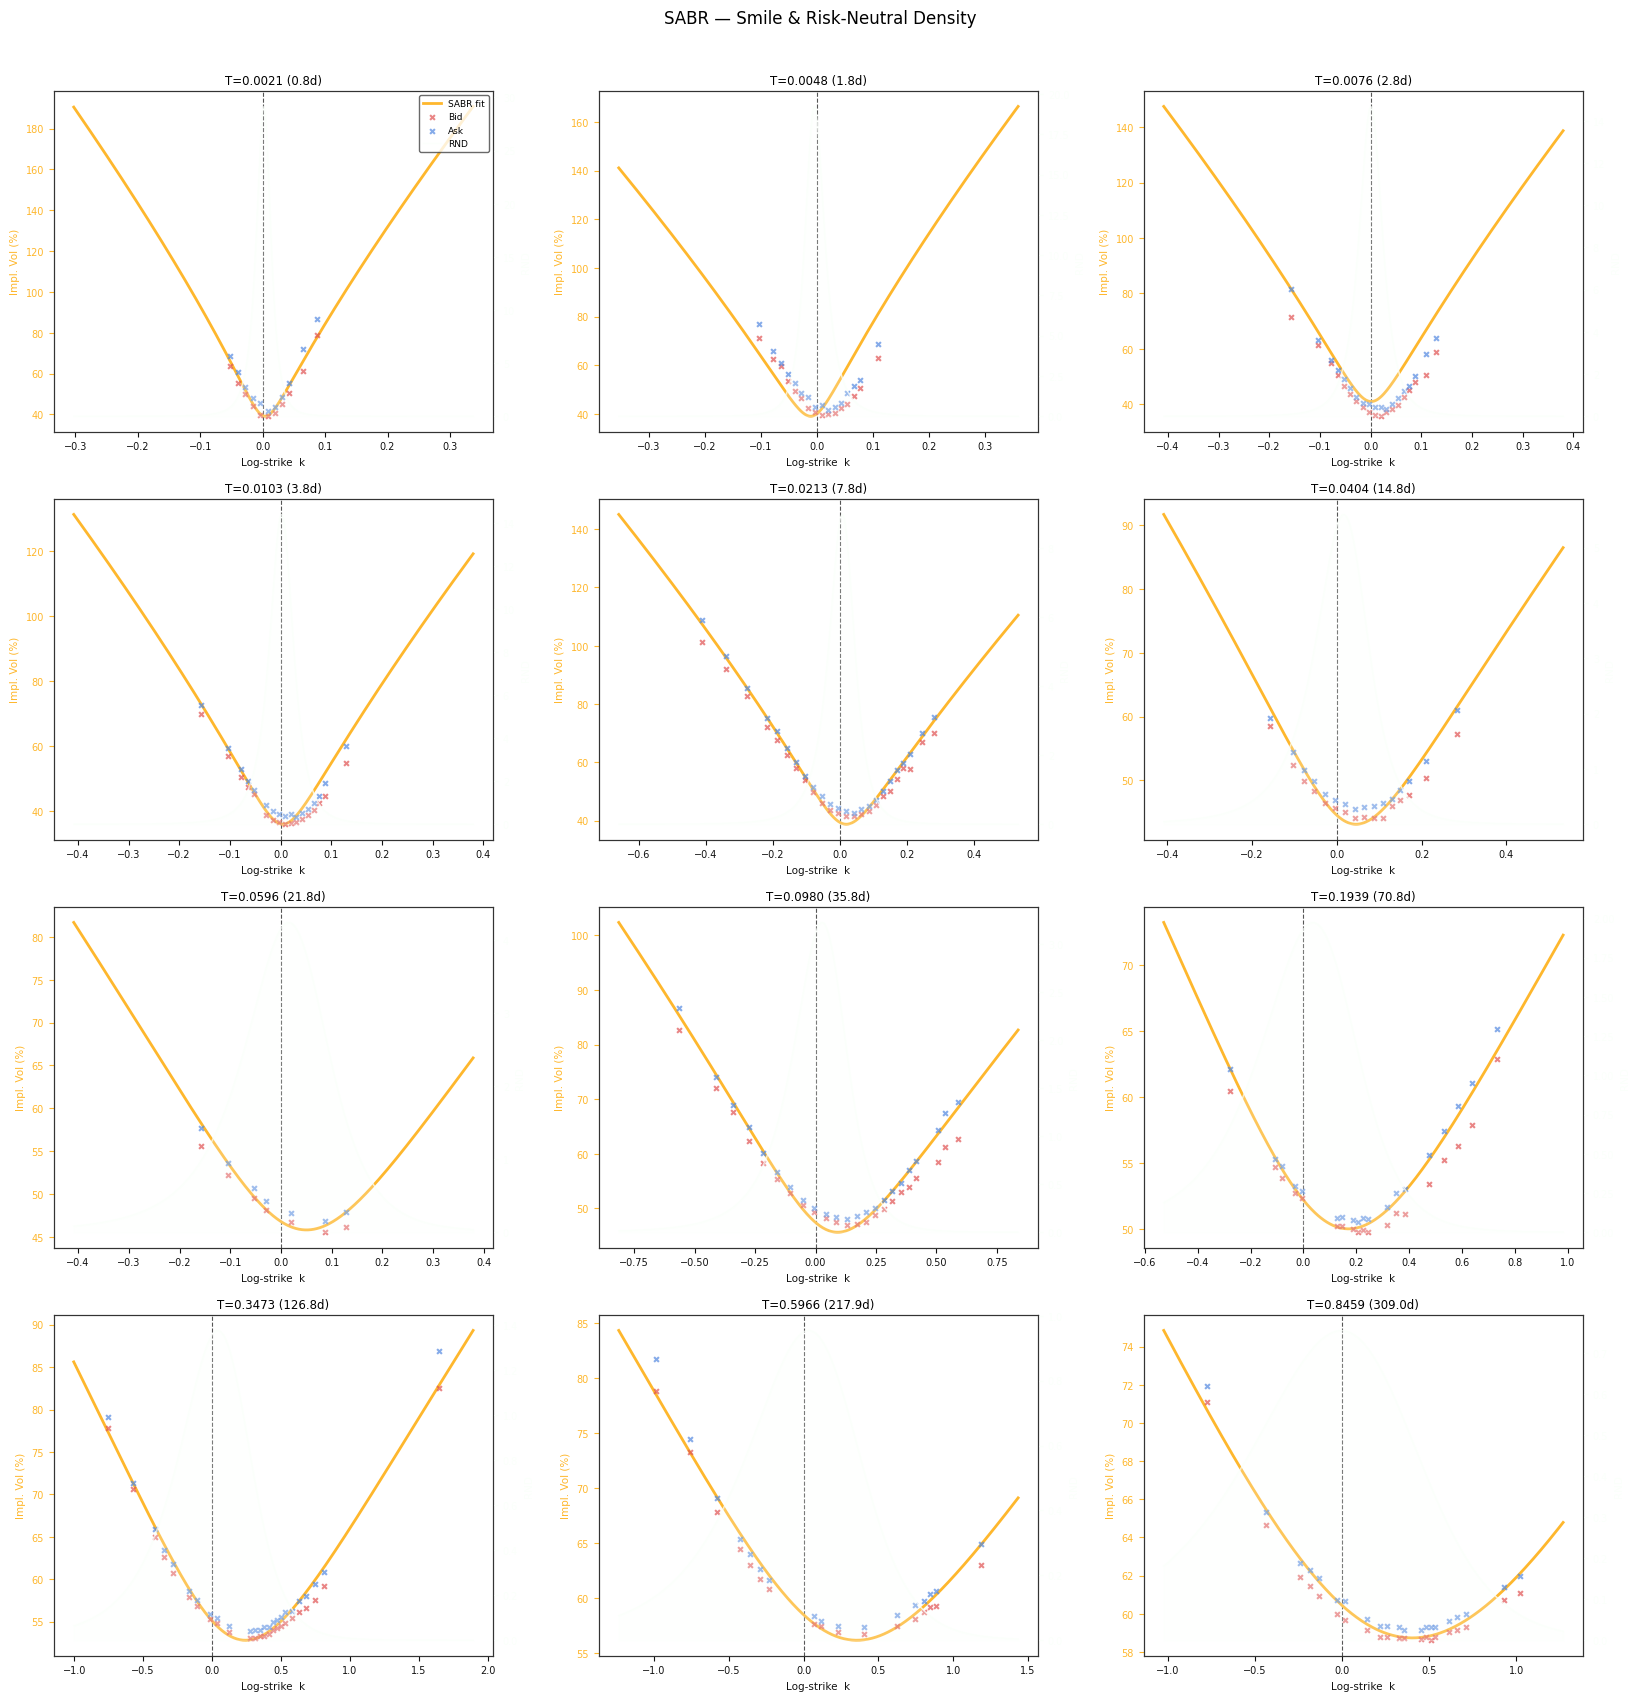

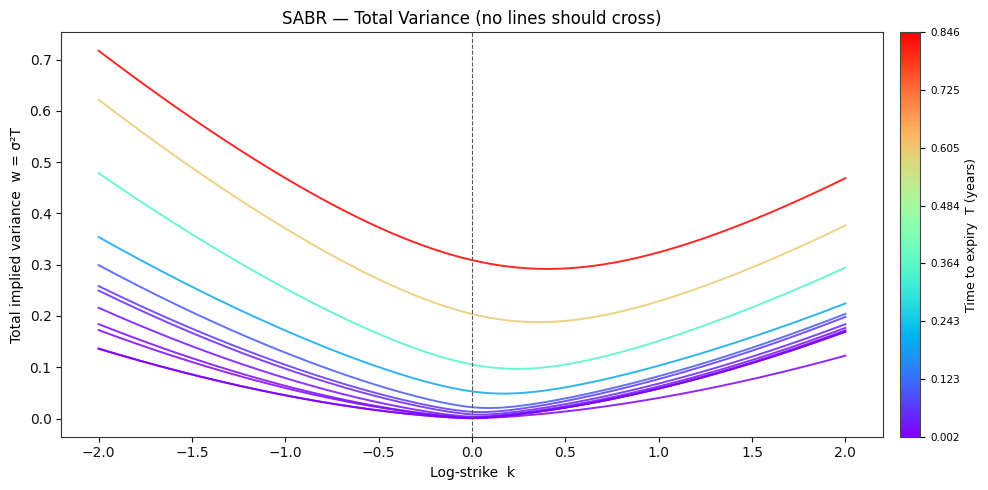

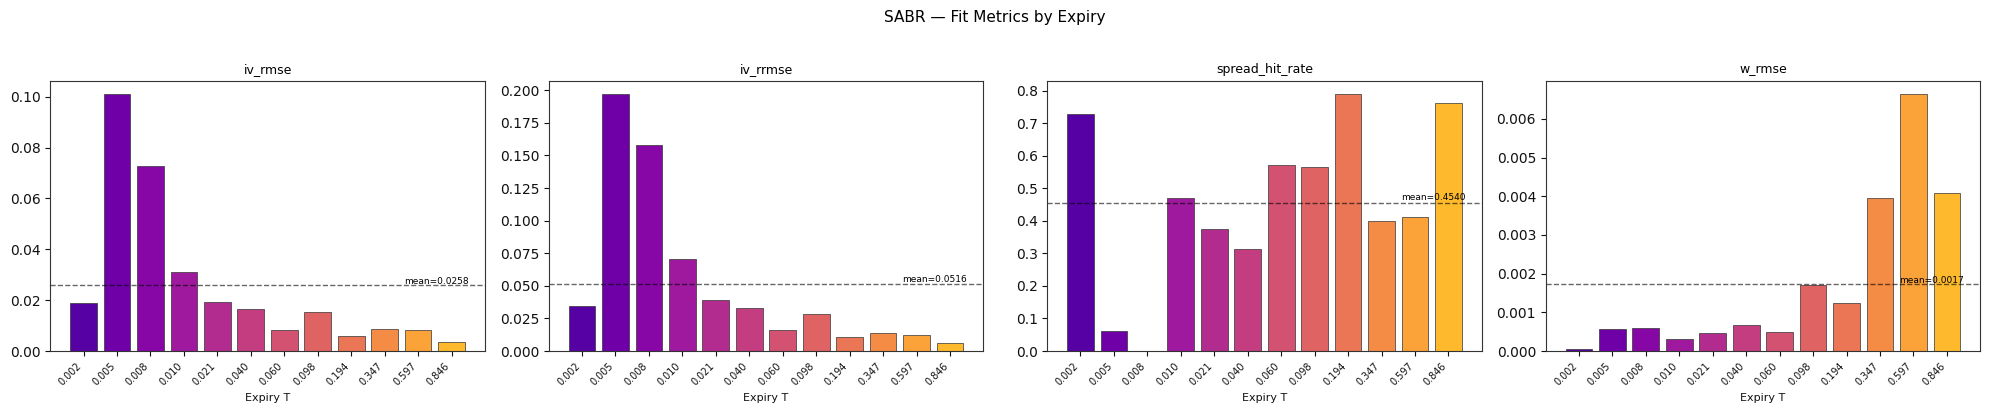

In [9]:
plot_all(sabr_ivrmse, df = eth);

In [11]:
t0 = time()
svi_ivrmse = calibrate_snapshot(df=eth, model = get_model('svi'), objective=get_objective('iv_rmse'), bid_col = 'bid_iv', ask_col='ask_iv',verbose=False)
t1 = time()
svi_vwmse = calibrate_snapshot(df=eth, model = get_model('svi'), objective=get_objective('vega_wmse'), bid_col = 'bid_iv', ask_col='ask_iv',verbose=False)
print(f'Time taken to calibrate eSSVI from a cold start using a vega WMSE objective function: {round(t1-t0, 1)}s')

Time taken to calibrate eSSVI from a cold start using a vega WMSE objective function: 21.1s


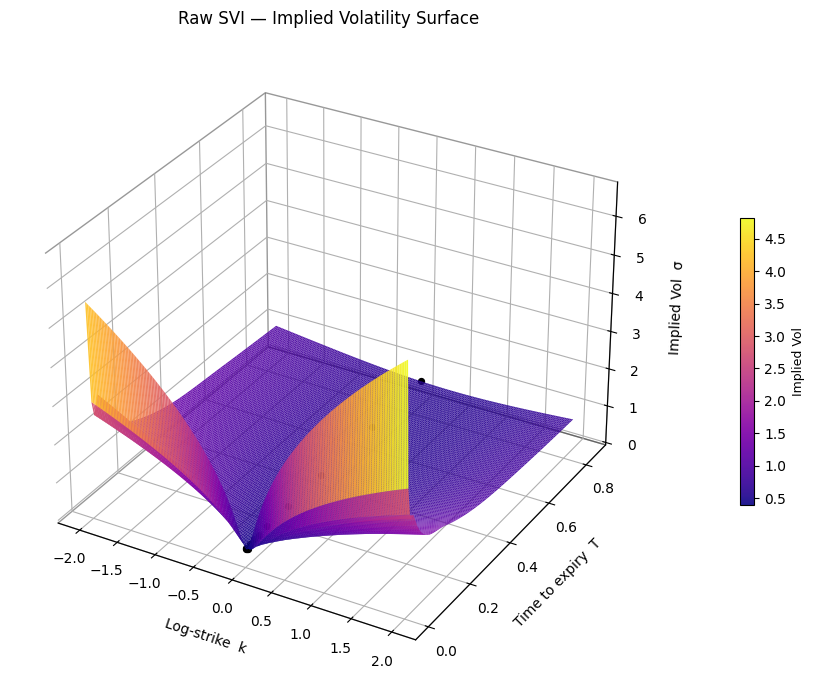

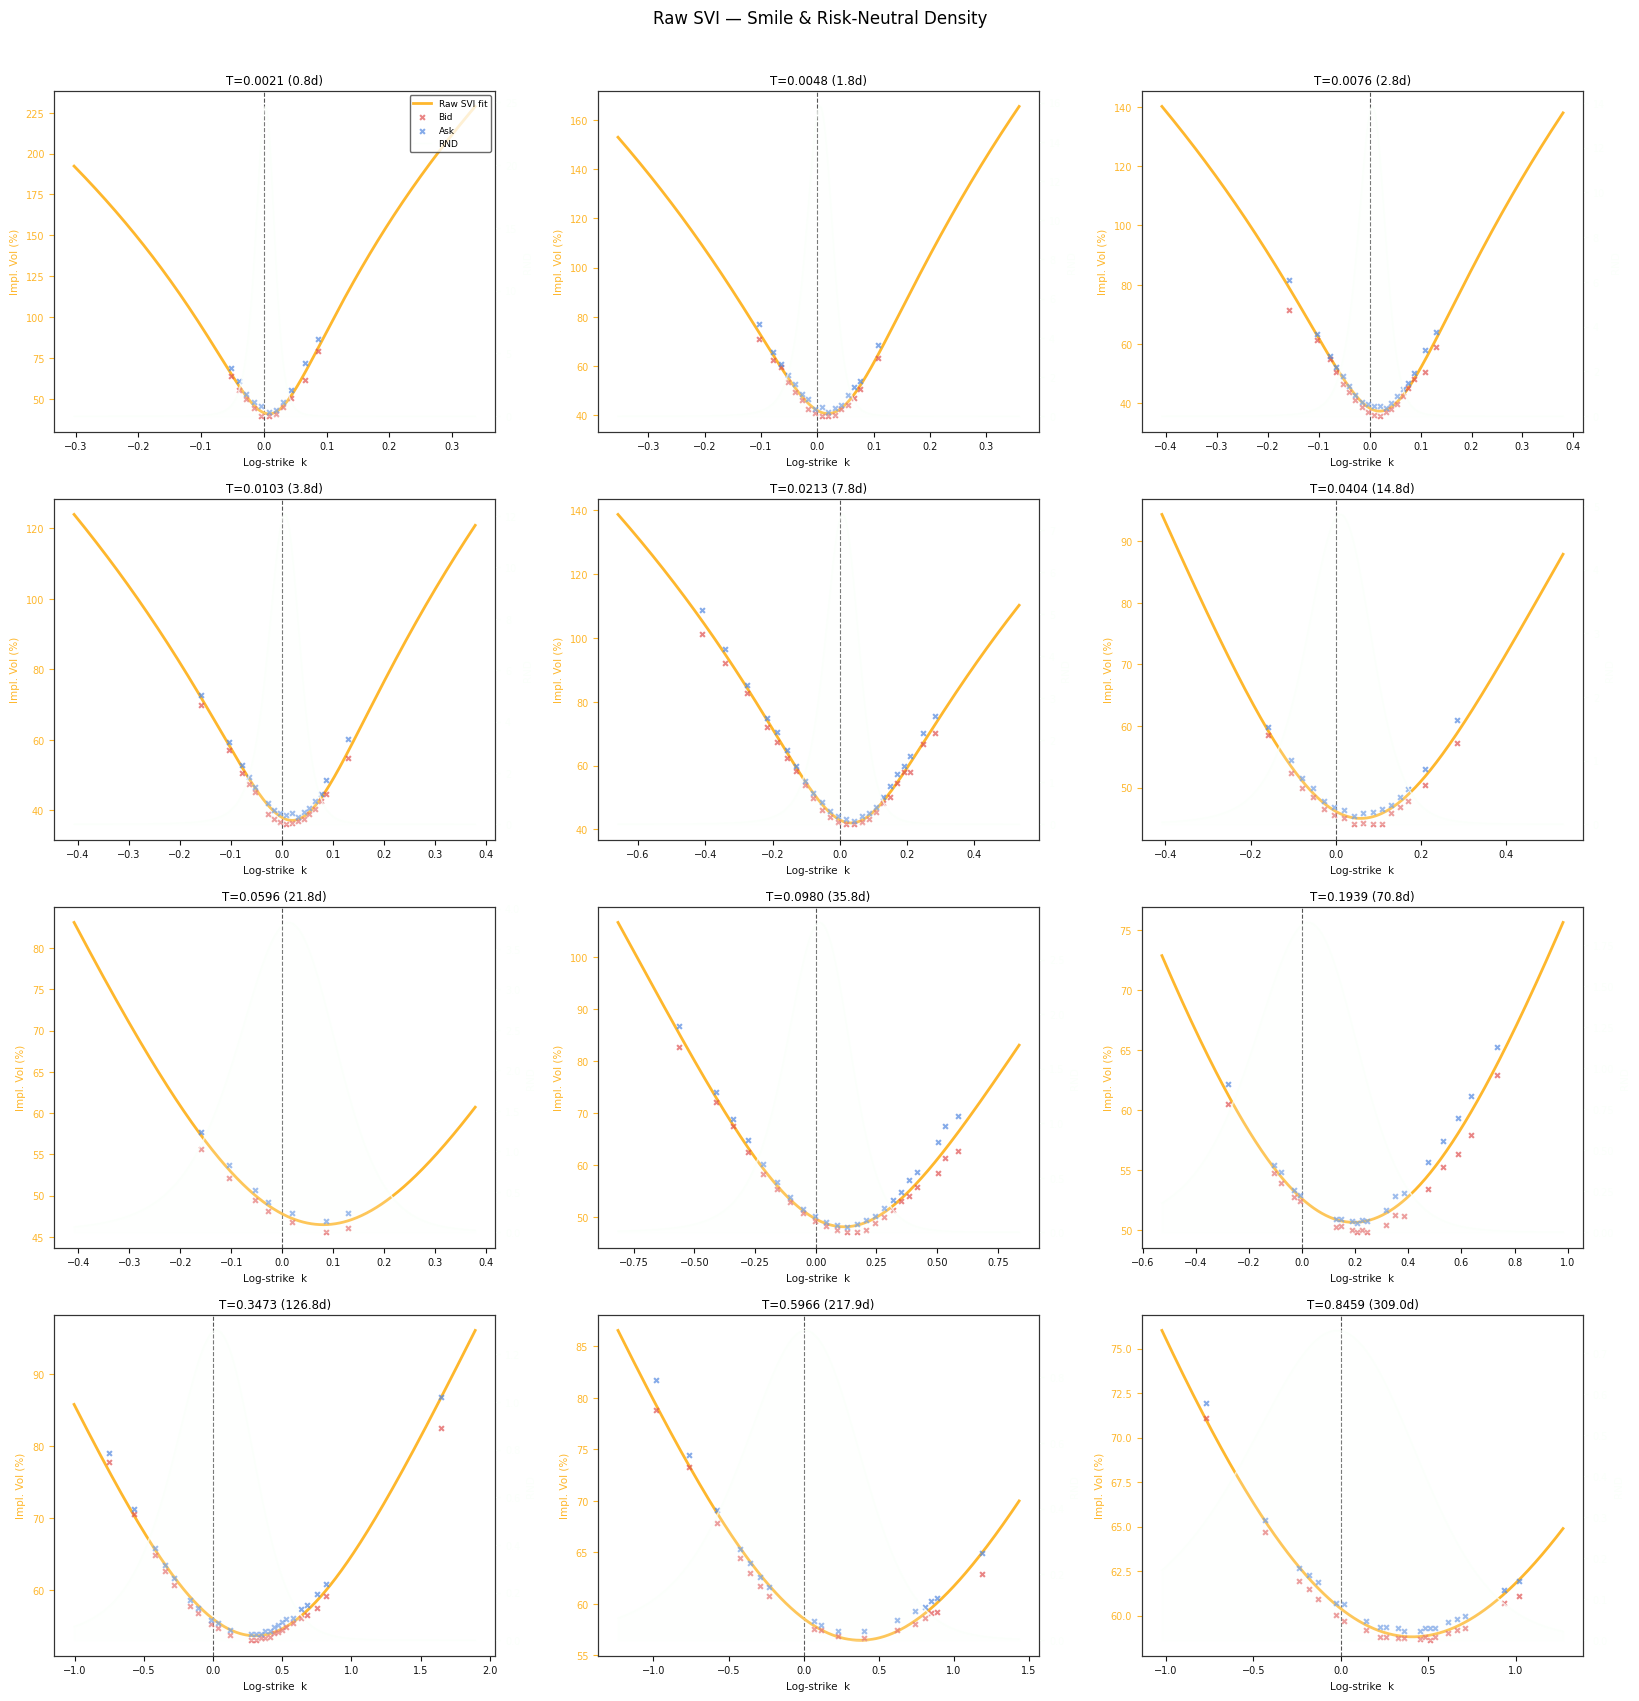

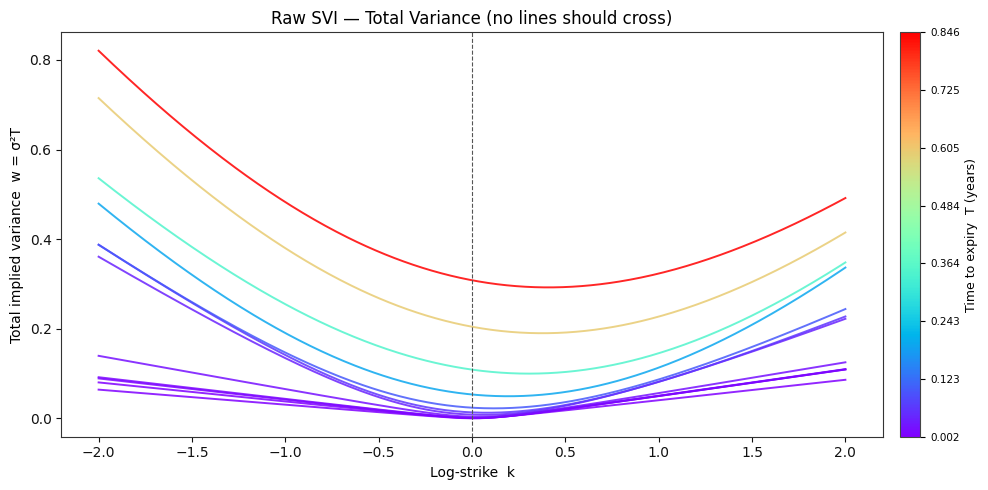

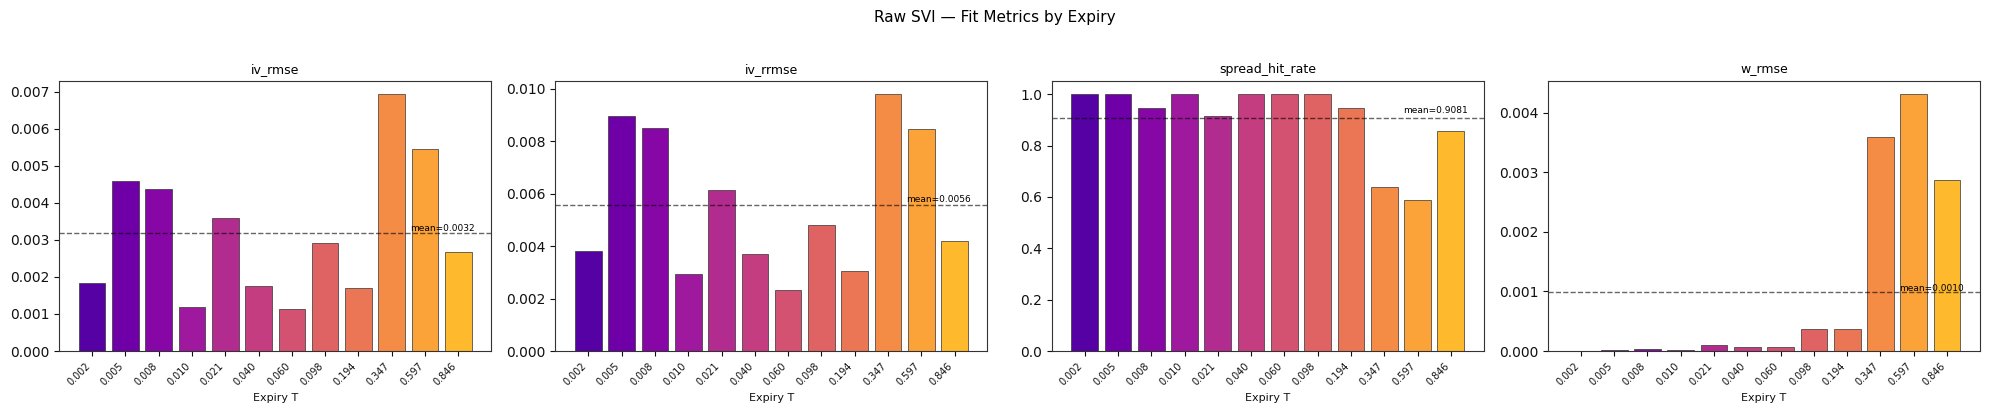

In [12]:
plot_all(svi_ivrmse, df=eth);

In [6]:
obj = get_objective('vega_wmse')
svi_vwmse = calibrate_snapshot(df=eth, model=get_model('svi'), objective=obj, bid_col = 'bid_iv', ask_col='ask_iv', verbose=False)
sabr_vwmse = calibrate_snapshot(df=eth, model=get_model('sabr'), objective=obj, bid_col = 'bid_iv', ask_col='ask_iv', verbose=False)
essvi_vwmse = calibrate_global_essvi(df=eth, model=get_model('essvi'), objective=obj, bid_col = 'bid_iv', ask_col='ask_iv', verbose=False)

In [15]:
sabr_vwmse = calibrate_snapshot(df=eth, model=get_model('sabr'), objective=obj, bid_col = 'bid_iv', ask_col='ask_iv', verbose=False)
sabr_pmse = calibrate_snapshot(df=eth, model=get_model('sabr'), objective=get_objective('price_mse'), bid_col = 'bid_iv', ask_col='ask_iv', verbose=False)

In [20]:
comparison = compare(sabr_vwmse, sabr_pmse)

              objective   iv_rmse  iv_rrmse  spread_hit_rate  price_rrmse    w_rmse  cal_arb_viol  atm_smoothness
model                                                                                                            
SABR   obj_iv_vega_wmse  0.015286  0.021301         0.823613     0.100149  0.003224           0.0        0.022322
SABR      obj_price_mse  0.013003  0.018373         0.821114     0.092951  0.002321           0.0        0.021849


In [5]:
(eth.spread/eth.mark_price).describe()
eth_clean = eth[(eth.spread/eth.mark_price)<0.5]
print(eth_clean.shape, eth.shape)

(211, 27) (215, 27)


In [6]:
obj = get_objective('vega_wmse')
svi_vwmse = calibrate_snapshot(df=eth_clean, model=get_model('svi'), objective=obj, bid_col = 'bid_iv', ask_col='ask_iv', verbose=False)
sabr_vwmse = calibrate_snapshot(df=eth_clean, model=get_model('sabr'), objective=obj, bid_col = 'bid_iv', ask_col='ask_iv', verbose=False)
essvi_vwmse = calibrate_global_essvi(df=eth_clean, model=get_model('essvi'), objective=obj, bid_col = 'bid_iv', ask_col='ask_iv', verbose=False)

In [7]:
obj = get_objective('iv_rmse')
svi_iv_rmse = calibrate_snapshot(df=eth_clean, model=get_model('svi'), objective=obj, bid_col = 'bid_iv', ask_col='ask_iv', verbose=False)
sabr_iv_rmse = calibrate_snapshot(df=eth_clean, model=get_model('sabr'), objective=obj, bid_col = 'bid_iv', ask_col='ask_iv', verbose=False)
essvi_iv_rmse = calibrate_global_essvi(df=eth_clean, model=get_model('essvi'), objective=obj, bid_col = 'bid_iv', ask_col='ask_iv', verbose=False)

In [8]:
obj = get_objective('price_mse')
svi_pmse = calibrate_snapshot(df=eth_clean, model=get_model('svi'), objective=obj, bid_col = 'bid_iv', ask_col='ask_iv', verbose=False)
sabr_pmse = calibrate_snapshot(df=eth_clean, model=get_model('sabr'), objective=obj, bid_col = 'bid_iv', ask_col='ask_iv', verbose=False)
essvi_pmse = calibrate_global_essvi(df=eth_clean, model=get_model('essvi'), objective=obj, bid_col = 'bid_iv', ask_col='ask_iv', verbose=False)

In [22]:
compare(svi_vwmse, sabr_vwmse, essvi_vwmse)

                objective   iv_rmse  iv_rrmse  spread_hit_rate  price_rrmse    w_rmse  cal_arb_viol  atm_smoothness
model                                                                                                              
Raw SVI  obj_iv_vega_wmse  0.005810  0.008099         0.949169     0.042741  0.001133           0.0        0.021846
SABR     obj_iv_vega_wmse  0.015151  0.020900         0.826804     0.093963  0.003226           0.0        0.022329
eSSVI    obj_iv_vega_wmse  0.024563  0.033642         0.688069     0.138847  0.003698           0.0        0.022639


,objective,iv_rmse,iv_rrmse,spread_hit_rate,price_rrmse,w_rmse,cal_arb_viol,atm_smoothness
model,,,,,,,,
Raw SVI,obj_iv_vega_wmse,0.005810,0.008099,0.949169,0.042741,0.001133,0.0,0.021846
SABR,obj_iv_vega_wmse,0.015151,0.020900,0.826804,0.093963,0.003226,0.0,0.022329
eSSVI,obj_iv_vega_wmse,0.024563,0.033642,0.688069,0.138847,0.003698,0.0,0.022639


# A FAIRE

Comparaison de fonction obj au sein des modeles
Comparaison des modeles avec la meme fonction obj 


eSSVI ok pour vanilla, not ok pour exos:
    eSSVI utilisé comme surface smooth non arbitrageable dans un SLV  

    voir antoine savine
    Voir bergomi